In [4]:
import numpy as np

# Define the input matrix representing our 5x5 single-channel input image
input_matrix = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

# Define the 3x3 filter/kernel which will slide across our input matrix
kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

# Configuration parameters for the 2D convolution process
stride = 1
padding = 0

def convolve2d(image, kernel, stride=1):
    """
    Performs a standard 2-D cross-correlation (convolution) of an input image with a kernel.

    Parameters:
      image  (numpy.ndarray): Input 2D matrix of shape (H, W)
      kernel (numpy.ndarray): Filter 2D matrix of shape (k_H, k_W)
      stride (int): Step size used when sliding the filter across the image

    Returns:
      numpy.ndarray: Resulting output feature map from the 2-D convolution
    """
    # Extract spatial dimensions of input image and kernel
    im_h, im_w = image.shape
    k_h, k_w = kernel.shape

    # Calculate height and width of output feature map using standard formula: ((W - F + 2P) / S) + 1
    out_h = int((im_h - k_h) / stride) + 1
    out_w = int((im_w - k_w) / stride) + 1

    # Initialize the output feature map with zeros
    output = np.zeros((out_h, out_w))

    # Slide the filter across each spatial location of the input
    for r in range(out_h):
        for c in range(out_w):
            # Extract the receptive field (local sub-grid of the input image)
            region = image[r*stride : r*stride + k_h, c*stride : c*stride + k_w]
            # Compute element-wise multiplication followed by sum (dot product equivalent)
            output[r, c] = np.sum(region * kernel)

    return output

# Execute convolution with Stride = 1
output_feature_map = convolve2d(input_matrix, kernel, stride=stride)
print("Output Feature Map (Stride=1):\n", output_feature_map)
print("Output Shape (Stride=1):", output_feature_map.shape)

# Execute convolution with Stride = 2 to fulfill Part II Question 1(f)
output_stride_2 = convolve2d(input_matrix, kernel, stride=2)
print("\nOutput Feature Map with Stride 2:\n", output_stride_2)
print("Output Shape with Stride 2:", output_stride_2.shape)

Output Feature Map:
 [[4. 3. 4.]
 [2. 4. 3.]
 [2. 3. 4.]]
Output Shape: (3, 3)

Output Feature Map with Stride 2:
 [[4. 4.]
 [2. 4.]]
Output Shape with Stride 2: (2, 2)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
import time
import matplotlib.pyplot as plt

# Detect and configure device; prioritize GPU acceleration if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define spatial and normalization pipelines for both training and validation sets
# We normalize the images using ImageNet statistics since we are using pretrained ImageNet weights
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),  # Resizing to 224x224 to match standard ResNet input dimensions
        transforms.RandomHorizontalFlip(),  # Augmentation to reduce risk of overfitting
        transforms.ToTensor(),  # Convert pixel values to PyTorch Tensors in range [0, 1.0]
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Standard ImageNet mean and std dev
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),  # Standard resizing for evaluation
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Retrieve and parse the CIFAR-10 Dataset locally
full_train_set = datasets.CIFAR10(root='./data', train=True, download=True)
full_test_set = datasets.CIFAR10(root='./data', train=False, download=True)

# Filter datasets for two distinct target classes (Airplane [label 0] and Automobile [label 1])
train_indices = [i for i, label in enumerate(full_train_set.targets) if label in [0, 1]]
test_indices = [i for i, label in enumerate(full_test_set.targets) if label in [0, 1]]

# Extract sub-selections of datasets to maintain optimal epoch times while verifying learning metrics
train_subset = Subset(datasets.CIFAR10(root='./data', train=True, transform=data_transforms['train']), train_indices[:1000])
val_subset = Subset(datasets.CIFAR10(root='./data', train=False, transform=data_transforms['val']), test_indices[:200])

# Map sub-selections to dataset loaders for structured mini-batch creation during validation and training phases
image_datasets = {'train': train_subset, 'val': val_subset}
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

Using device: cuda


100%|██████████| 170M/170M [13:02<00:00, 218kB/s]


In [6]:
def train_model(model, criterion, optimizer, num_epochs=3):
    """
    Core training loop function that processes model learning over train/val phases for a specific number of epochs.

    Parameters:
      model: PyTorch NN model instance to train
      criterion: Loss objective function (CrossEntropyLoss)
      optimizer: Parameter weight optimization algorithm
      num_epochs: Total full passes through the training subset

    Returns:
      model: Trained PyTorch NN model
      loss_history: List of average training losses recorded per epoch
      final_val_acc: Validation accuracy achieved in the last epoch
      time_elapsed: Runtime duration in seconds
    """
    since = time.time()
    loss_history = []
    accuracy_history = []

    # Loop sequentially over each epoch
    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        # Alternate between Training and Validation loops
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Activates dropout and batch normalization updates
            else:
                model.eval()   # Deactivates dropout and utilizes rolling batch statistics

            running_loss = 0.0
            running_corrects = 0

            # Iterate in batches over the data loader
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Reset gradients before executing backpropagation
                optimizer.zero_grad()

                # Enable parameter gradient computation ONLY during training phase
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Execute backpropagation and weight optimizations if in training mode
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Track cumulative batch metrics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Average out cumulative epoch performance indicators
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Store historic progression for plotting and tracking comparisons
            if phase == 'train':
                loss_history.append(epoch_loss)
            else:
                accuracy_history.append(epoch_acc.item())
        print()

    # Calculate runtime performance and compile training time data
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, loss_history, accuracy_history[-1], time_elapsed

In [7]:
# ==========================================
# Experiment A: Feature Extraction (Frozen)
# ==========================================
print("=== Starting Experiment A: Feature Extraction ===")

# Instantiate a standard ResNet18 backbone using pretrained ImageNet model parameters
model_conv = models.resnet18(pretrained=True)

# Freeze weights across all primary convolutional base feature extraction layers
# This ensures no gradients are calculated or updated within these layers during training
for param in model_conv.parameters():
    param.requires_grad = False

# Extract input features from the final fully connected classification layer
num_ftrs = model_conv.fc.in_features

# Replace original final layer with a new custom linear classifier mapped to 2 output classes
# The new layer has requires_grad=True automatically upon creation
model_conv.fc = nn.Linear(num_ftrs, 2)
model_conv = model_conv.to(device)

# Count and display active trainable parameters; this should only equal the weights/biases of the fc layer
trainable_params_a = sum(p.numel() for p in model_conv.parameters() if p.requires_grad)
print(f"Trainable Parameters in Exp A: {trainable_params_a}")

# Set the classification loss metric (cross entropy loss for multiclass problems)
criterion = nn.CrossEntropyLoss()

# Pass only the classifier weights to the optimizer; remaining network weights are untouched
optimizer_conv = optim.Adam(model_conv.fc.parameters(), lr=0.001)

# Execute training for Experiment A
model_conv, loss_history_a, accuracy_a, time_a = train_model(model_conv, criterion, optimizer_conv, num_epochs=3)

=== Starting Experiment A: Feature Extraction ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Trainable Parameters in Exp A: 1026
Epoch 1/3
----------
train Loss: 0.6008 Acc: 0.6610
val Loss: 0.4044 Acc: 0.8800

Epoch 2/3
----------
train Loss: 0.3437 Acc: 0.8670
val Loss: 0.2790 Acc: 0.9450

Epoch 3/3
----------
train Loss: 0.2636 Acc: 0.9120
val Loss: 0.2369 Acc: 0.9300

Training complete in 0m 8s


In [8]:
# ==========================================
# Experiment B: Fine-Tuning (Unfrozen base layers)
# ==========================================
print("\n=== Starting Experiment B: Fine-Tuning ===")

# Instantiate another ResNet18 backbone using pretrained parameters
model_ft = models.resnet18(pretrained=True)

# Freeze all convolutional backbone layers initially to prevent massive global updates
for param in model_ft.parameters():
    param.requires_grad = False

# Selectively unfreeze layer 4 (the final deep convolutional layer block of ResNet18)
# This allows high-level abstract representation layers to adapt directly to the new dataset structure
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# Extract and replace the final fully connected classifier output layer for our 2 classes
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)
model_ft = model_ft.to(device)

# Count trainable parameters; this now includes layer4 weights and custom classification layer weights
trainable_params_b = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f"Trainable Parameters in Exp B: {trainable_params_b}")

# Configure custom layered optimization updates: lower learning rate for layer4, standard rate for fc classifier
optimizer_ft = optim.Adam([
    {'params': model_ft.layer4.parameters(), 'lr': 1e-4},
    {'params': model_ft.fc.parameters(), 'lr': 1e-3}
])

# Execute training for Experiment B
model_ft, loss_history_b, accuracy_b, time_b = train_model(model_ft, criterion, optimizer_ft, num_epochs=3)


=== Starting Experiment B: Fine-Tuning ===
Trainable Parameters in Exp B: 8394754
Epoch 1/3
----------
train Loss: 0.1912 Acc: 0.9150
val Loss: 0.0635 Acc: 0.9800

Epoch 2/3
----------
train Loss: 0.0492 Acc: 0.9840
val Loss: 0.0833 Acc: 0.9700

Epoch 3/3
----------
train Loss: 0.0240 Acc: 0.9910
val Loss: 0.0724 Acc: 0.9650

Training complete in 0m 8s


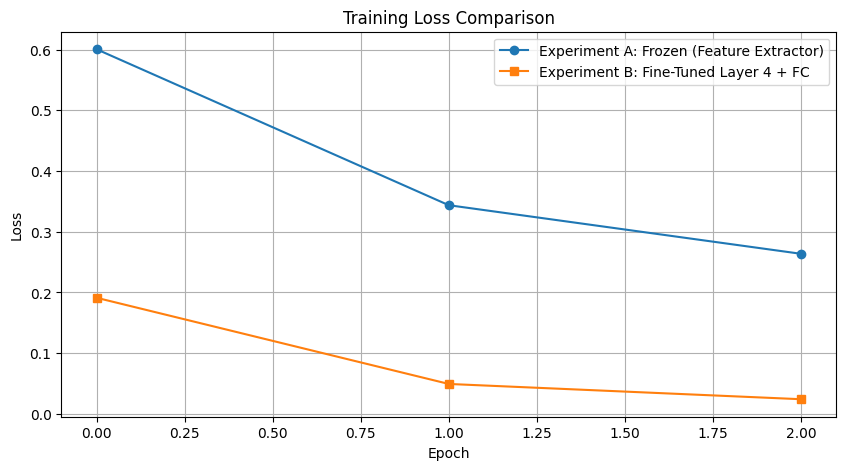


Comparison Table:
                  Method  Trainable Parameters  Training Time (s) Accuracy
Frozen Feature Extractor                  1026               8.06   93.00%
      Fine-Tuned Network               8394754               8.11   96.50%


In [9]:
# Initialize a single plot layout comparing the loss histories of both training experiments
plt.figure(figsize=(10, 5))
plt.plot(loss_history_a, label='Experiment A: Frozen (Feature Extractor)', marker='o')
plt.plot(loss_history_b, label='Experiment B: Fine-Tuned Layer 4 + FC', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison: Feature Extraction vs Fine-Tuning')
plt.legend()
plt.grid(True)
plt.show()

# Load tabular framework metrics from both experiments for side-by-side comparison
import pandas as pd
data = {
    "Method": ["Frozen Feature Extractor", "Fine-Tuned Network"],
    "Trainable Parameters": [trainable_params_a, trainable_params_b],
    "Training Time (s)": [round(time_a, 2), round(time_b, 2)],
    "Accuracy": [f"{accuracy_a * 100:.2f}%", f"{accuracy_b * 100:.2f}%"]
}
df = pd.DataFrame(data)
print("\nComparison Table:")
print(df.to_string(index=False))